In [1]:
import numpy as np;
import pandas as pd;
import seaborn as sns;
import matplotlib.pyplot as plt;
import warnings 
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('D:\ML\machne\housing.csv')

In [3]:
df.shape

(20640, 10)

In [4]:
df.drop_duplicates(inplace=True)
df.shape

(20640, 10)

In [5]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [7]:
df.corr(numeric_only=True)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000


In [8]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [9]:
df['ocean_proximity'].value_counts()
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [10]:
df['total_bedrooms']=df['total_bedrooms'].fillna(df['total_bedrooms'].mean())
cos=['longitude', 'latitude', 'housing_median_age', 'total_rooms','total_bedrooms', 'population', 'households', 'median_income','median_house_value', 'ocean_proximity']

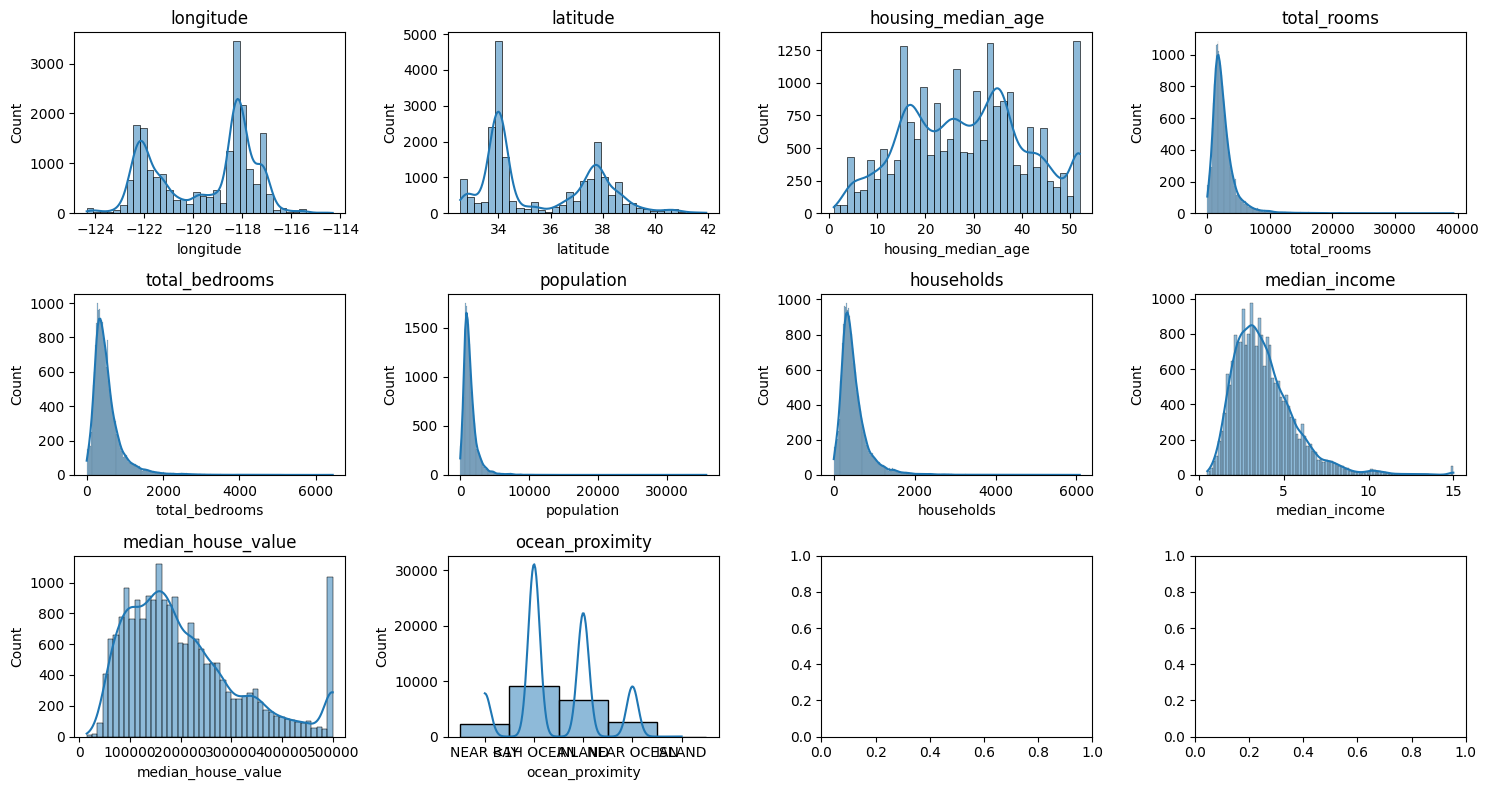

In [11]:
fig, axes = plt.subplots(3, 4, figsize=(15, 8))
for i, col in enumerate(cos):
    sns.histplot(x=col, data=df, ax=axes[i//4, i%4],kde=True)
    axes[i//4, i%4].set_title(col)

plt.tight_layout()
plt.show()

In [12]:
df=pd.get_dummies(df,columns=['ocean_proximity'])

In [13]:
catcos=['ocean_proximity_INLAND','ocean_proximity_<1H OCEAN','ocean_proximity_NEAR OCEAN','ocean_proximity_NEAR BAY']
drop=['ocean_proximity_ISLAND','households','population','total_bedrooms','longitude']
for n in drop:
    df=df.drop(n,axis=1)


In [14]:
for n in catcos:
    df[n]=df[n].astype(int)

In [15]:
df.rename(columns={'ocean_proximity_<1H OCEAN':'ocean_proximity_1H OCEAN'},inplace=True)


In [16]:
from sklearn.model_selection import train_test_split
x=df.drop('median_house_value',axis=1)
y=df['median_house_value']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)


In [17]:
from sklearn.metrics import r2_score,accuracy_score,mean_squared_error
r2=r2_score(y_test,y_pred)
r2

0.5871101407304827

In [18]:
from sklearn.model_selection import cross_val_score
score=cross_val_score(model,x,y,cv=5,scoring='r2')
print(score)

[0.42087027 0.41604386 0.56454606 0.42138645 0.65458663]


In [19]:
print(score.mean())

0.49548665444879847


In [20]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,f1_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,accuracy_score,mean_squared_error
models={
    "DecisionTree":DecisionTreeRegressor(random_state=42,max_depth=5),
    "svr":SVR(kernel='rbf',C=1e3,epsilon=0.1),
    "model2":RandomForestRegressor(n_estimators=200,random_state=42),
        }
for name,model1 in models.items():
    model1.fit(x_train,y_train)
    pred=model1.predict(x_test)
    r2=r2_score(y_test,y_pred)
    print(f"{name},accuracy:{r2}")


DecisionTree,accuracy:0.5871101407304827
svr,accuracy:0.5871101407304827
model2,accuracy:0.5871101407304827


In [22]:
x_train.columns=x_train.columns.map(str)
x_test.columns=x_test.columns.map(str)
import xgboost as xgb
md=xgb.XGBRegressor(objective='reg:squarederror',max_depth=5,learning_rate=0.1,n_estimators=1000,n_jobs=-1)
md.fit(x_train,y_train)
pred=md.predict(x_test)
r2=r2_score(y_test,y_pred)
r2


0.7018720911361549

In [24]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
kfod=KFold(n_splits=5,shuffle=True,random_state=42)
scores=cross_val_score(md,x,y,cv=kfod,scoring='r2')
print(scores)


[0.71394492 0.72761882 0.71242426 0.73825293 0.71456429]


In [26]:
print(scores.mean())

0.7213610438223792
